# Convolutional Variational Autoencoder for CelebA Face Images

128×128 RGB CelebA faces, trained with a sigmoid decoder and mean-squared reconstruction loss.

## Imports

In [1]:
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt

from helper_data import get_dataloaders_celeba
from helper_train import train_vae_v1
from helper_utils import set_all_seeds
from helper_plotting import plot_generated_images, plot_images_sampled_from_vae, plot_training_loss

## Settings

In [2]:
RANDOM_SEED = 123
LEARNING_RATE = 0.0005
BATCH_SIZE = 256
NUM_EPOCHS = 50
LATENT_SIZE = 200
NUM_WORKERS = 2

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
set_all_seeds(RANDOM_SEED)

Device: cuda:0


## Dataset

In [3]:
from torchvision import transforms

custom_transforms = transforms.Compose([
    transforms.CenterCrop((128, 128)),
    transforms.ToTensor(),
])

train_loader, valid_loader, test_loader = get_dataloaders_celeba(
    batch_size=BATCH_SIZE,
    train_transforms=custom_transforms,
    test_transforms=custom_transforms,
    num_workers=NUM_WORKERS,
    download=False,
)

## Model

In [4]:
class Reshape(nn.Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return x.view(self.shape)


class Trim(nn.Module):
    def forward(self, x):
        return x[:, :, :128, :128]


class VAE(nn.Module):
    def __init__(self, latent_size=LATENT_SIZE):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            nn.Flatten(),
        )

        self.z_mean = nn.Linear(4096, latent_size)
        self.z_log_var = nn.Linear(4096, latent_size)

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 4096),
            Reshape(-1, 64, 8, 8),
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1),
            Trim(),
            nn.Sigmoid(),
        )

    def encoding_fn(self, x):
        features = self.encoder(x)
        z_mean = self.z_mean(features)
        z_log_var = self.z_log_var(features)
        return self.reparameterize(z_mean, z_log_var)

    def reparameterize(self, z_mean, z_log_var):
        eps = torch.randn_like(z_mean)
        return z_mean + eps * torch.exp(z_log_var / 2.0)

    def forward(self, x):
        features = self.encoder(x)
        z_mean = self.z_mean(features)
        z_log_var = self.z_log_var(features)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded, z_mean, z_log_var, decoded

In [5]:
set_all_seeds(RANDOM_SEED)
model = VAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1, inplace=True)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1, inplace=True)
    (11): Dropout2d(p=0.25, inplace=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNorm2d(64, eps=1e-05

## Training

In [6]:
log_dict = train_vae_v1(
    num_epochs=NUM_EPOCHS,
    model=model,
    optimizer=optimizer,
    device=DEVICE,
    train_loader=train_loader,
    skip_epoch_stats=True,
    logging_interval=50,
    save_model='vae_celeba_02.pt',
)

/home/rise-racing/Desktop/JIUUOO/today-i-learned/autoencoders-generative-models/vae/helper_train.py:202: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  print('Epoch: %03d/%03d | Batch %04d/%04d | Loss: %.4f'


Epoch: 001/050 | Batch 0000/0636 | Loss: 5484.0913
Epoch: 001/050 | Batch 0050/0636 | Loss: 2133.0630
Epoch: 001/050 | Batch 0100/0636 | Loss: 1468.8732
Epoch: 001/050 | Batch 0150/0636 | Loss: 1222.1150
Epoch: 001/050 | Batch 0200/0636 | Loss: 1098.1255
Epoch: 001/050 | Batch 0250/0636 | Loss: 1064.5262
Epoch: 001/050 | Batch 0300/0636 | Loss: 963.5388
Epoch: 001/050 | Batch 0350/0636 | Loss: 976.4437
Epoch: 001/050 | Batch 0400/0636 | Loss: 929.8250
Epoch: 001/050 | Batch 0450/0636 | Loss: 919.0110
Epoch: 001/050 | Batch 0500/0636 | Loss: 921.5664
Epoch: 001/050 | Batch 0550/0636 | Loss: 879.8553
Epoch: 001/050 | Batch 0600/0636 | Loss: 857.5517
Time elapsed: 0.34 min
Epoch: 002/050 | Batch 0000/0636 | Loss: 843.1759
Epoch: 002/050 | Batch 0050/0636 | Loss: 810.5995
Epoch: 002/050 | Batch 0100/0636 | Loss: 823.5119
Epoch: 002/050 | Batch 0150/0636 | Loss: 811.2127
Epoch: 002/050 | Batch 0200/0636 | Loss: 792.2760
Epoch: 002/050 | Batch 0250/0636 | Loss: 780.7034
Epoch: 002/050 | Batc

## Evaluation

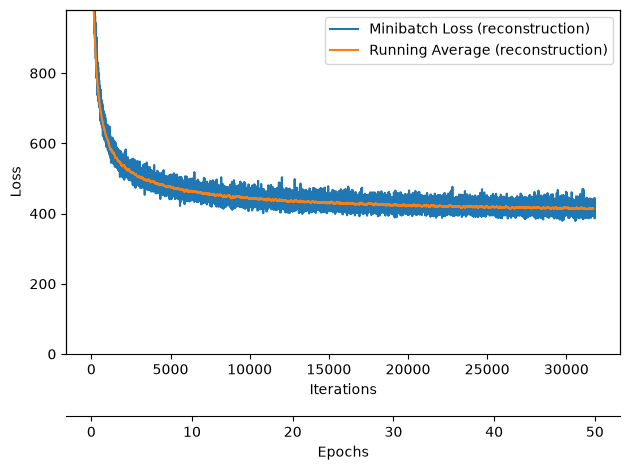

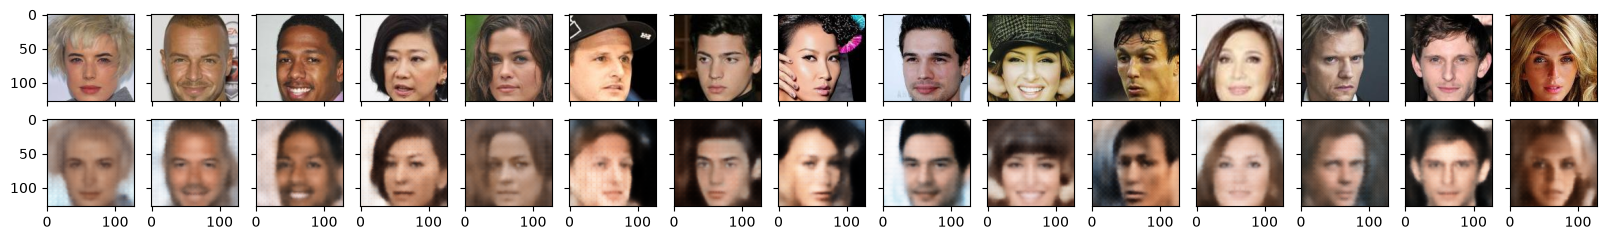

In [7]:
plot_training_loss(
    log_dict['train_reconstruction_loss_per_batch'],
    NUM_EPOCHS,
    custom_label=' (reconstruction)',
)
plt.show()

plot_generated_images(
    data_loader=train_loader, model=model, device=DEVICE, modeltype='VAE'
)
plt.show()

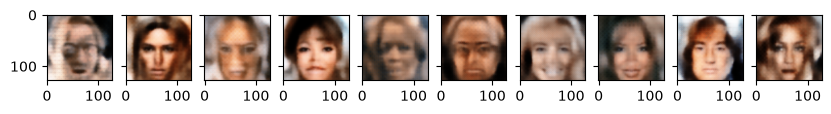

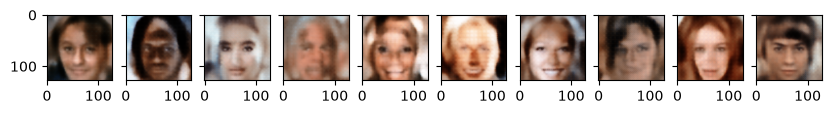

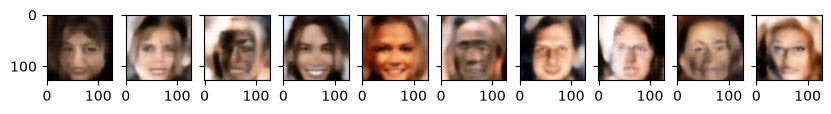

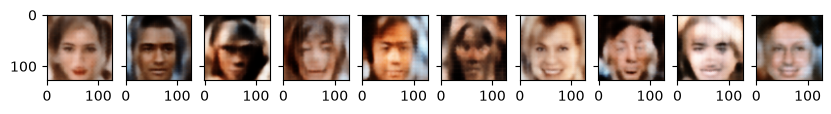

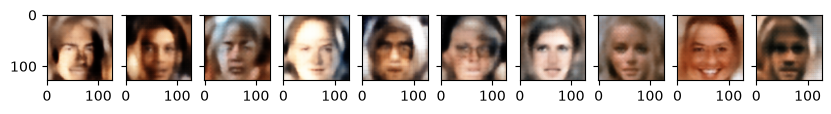

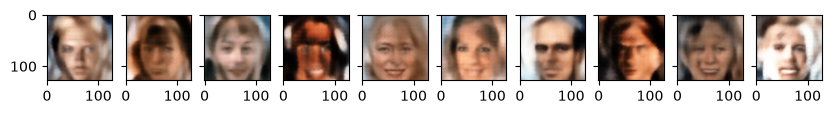

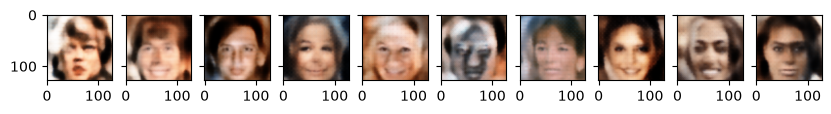

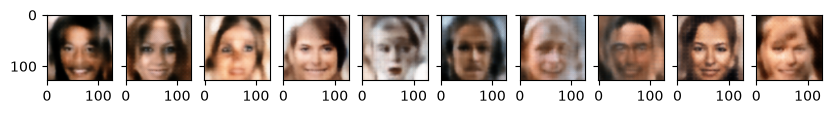

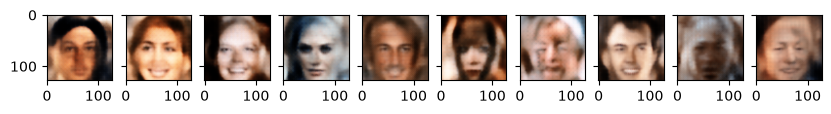

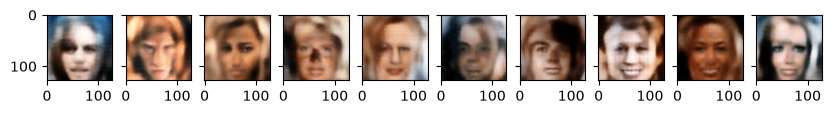

In [8]:
for _ in range(10):
    plot_images_sampled_from_vae(
        model=model, device=DEVICE, latent_size=LATENT_SIZE
    )
    plt.show()